# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Hilal TSabitul Azmi Arba'i | 5054251008 |
## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [308]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import (
    CategoricalNB,
    BernoulliNB,
    MultinomialNB
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

In [309]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

"""Attribute Information: (classes: edible=e, poisonous=p)"""
# cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
# cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
# cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
# bruises: bruises=t,no=f
# odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s
# gill-attachment: attached=a,descending=d,free=f,notched=n
# gill-spacing: close=c,crowded=w,distant=d
# gill-size: broad=b,narrow=n
# gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y
# stalk-shape: enlarging=e,tapering=t
# stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?
# stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
# stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
# stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
# stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
# veil-type: partial=p,universal=u
# veil-color: brown=n,orange=o,white=w,yellow=y
# ring-number: none=n,one=o,two=t
# ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
# spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
# population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
# habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

data = pd.read_csv("mushrooms.csv")
data.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


In [310]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

In [311]:
data.shape

(8124, 23)

In [312]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [313]:
print("data pada kolom stalk root yang berisi (?) : ", data["stalk-root"].isin(["?"]).sum())

data pada kolom stalk root yang berisi (?) :  2480


In [314]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

In [315]:
data.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [316]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

class
e    4208
p    3916
Name: count, dtype: int64

Proporsi kelas (%):
class
e    51.8
p    48.2
Name: count, dtype: float64


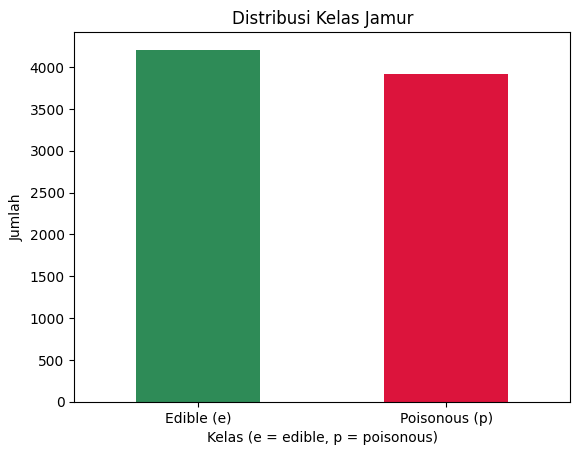

In [317]:
class_counts = data["class"].value_counts()

ax = class_counts.plot(
    kind="bar",
    color=["seagreen", "crimson"],
    title="Distribusi Kelas Jamur"
)

ax.set_xlabel("Kelas (e = edible, p = poisonous)")
ax.set_ylabel("Jumlah")
ax.set_xticklabels(["Edible (e)", "Poisonous (p)"], rotation=0)

print(class_counts)
print("\nProporsi kelas (%):")
print((class_counts / len(data) * 100).round(2))

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [318]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

In [319]:
data_unknown = data.copy()
data_unknown["stalk-root"] = data_unknown["stalk-root"].replace("?", "unknown")

In [320]:
print((data_unknown["stalk-root"] == "?").sum())

0


In [321]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

In [322]:
data.drop(columns=["veil-type"], inplace=True)
print("Kolom setelah penghapusan:")
print(data.columns.tolist())

data_unknown.drop(columns= ["veil-type"], inplace= True)
print("Kolom setelah penghapusan: ")
print(data_unknown.columns.tolist())

Kolom setelah penghapusan:
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Kolom setelah penghapusan: 
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [323]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

In [324]:
# Pisahkan fitur dan target dari data yang sudah dibersihkan
X = data_unknown.drop(columns=["class"])
y = data_unknown["class"].map({"e": 0, "p": 1})

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train value counts:\n", y_train.value_counts().sort_index())

x_train shape: (6499, 21)
x_test shape: (1625, 21)
y_train value counts:
 class
0    3366
1    3133
Name: count, dtype: int64


In [325]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

In [326]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value= -1, dtype= np.int64)
x_train_encoded = encoder.fit_transform(x_train)
x_test_encoded = encoder.transform(x_test)

print("nilai minimum train: ", x_train_encoded.min())
print("nilai minimum test: ", x_test_encoded.min())

nilai minimum train:  0
nilai minimum test:  0


In [327]:
encoded_df = pd.DataFrame(x_train_encoded, columns=x_train.columns)
encoded_df.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,2,3,9,0,2,1,0,0,2,0,...,1,1,6,0,2,1,2,1,5,1
1,5,2,5,1,5,1,0,0,1,0,...,2,2,2,7,2,2,0,7,1,6
2,0,2,3,0,5,1,1,0,10,0,...,1,2,7,7,2,2,4,7,3,1
3,2,2,4,0,7,1,0,1,0,1,...,1,1,6,7,2,1,0,7,4,0
4,3,3,4,0,2,1,0,1,0,1,...,2,1,6,6,2,1,0,7,4,4


In [328]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

In [329]:
onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)
x_train_onehot = onehot_encoder.fit_transform(x_train)
x_test_onehot = onehot_encoder.transform(x_test)

In [330]:
print("sebelum one hot: ", x_train.shape)
print("setelah one hot: ", x_train_onehot.shape)

sebelum one hot:  (6499, 21)
setelah one hot:  (6499, 116)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [331]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

In [332]:
categorical_nb = CategoricalNB(alpha= 1.0)
categorical_nb.fit(
    x_train_encoded,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [333]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

In [334]:
categorical_pred = categorical_nb.predict(
    x_test_encoded
)

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [335]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

In [336]:

bernoulli_nb = BernoulliNB(
    alpha= 1.0
)

bernoulli_nb.fit(
    x_train_onehot,
    y_train
)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [337]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

In [338]:
bernoulli_pred = bernoulli_nb.predict(
    x_test_onehot
)

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [339]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

In [340]:
multinomial_nb = MultinomialNB(
    alpha= 1.0
)

multinomial_nb.fit(
    x_train_onehot,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [341]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

In [342]:
multinomial_pred = multinomial_nb.predict(
    x_test_onehot
)

In [343]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "CategoricalNB": categorical_pred,
    "BernoulliNB": bernoulli_pred,
    "MultinomialNB": multinomial_pred
})

prediction_comparison.head(10)

,Actual,CategoricalNB,BernoulliNB,MultinomialNB
0,1,1,1,1
1,1,0,0,0
2,0,0,0,0
3,1,1,1,1
4,1,1,1,1
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,1,0,0,0


# 4. Evaluasi Model

In [344]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

In [345]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    positive_label="p"
):
    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        )
    }

In [346]:
evaluation_results = [
    evaluate_model(
        "CategoricalNB",
        y_test,
        categorical_pred,
        positive_label=1
    ),

    evaluate_model(
        "BernoulliNB",
        y_test,
        bernoulli_pred,
        positive_label=1
    ),

    evaluate_model(
        "MultinomialNB",
        y_test,
        multinomial_pred,
        positive_label=1
    )
]

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,CategoricalNB,0.945846,0.990127,0.896552,0.941019
1,BernoulliNB,0.932923,0.981429,0.877395,0.926500
2,MultinomialNB,0.945846,0.990127,0.896552,0.941019


In [347]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

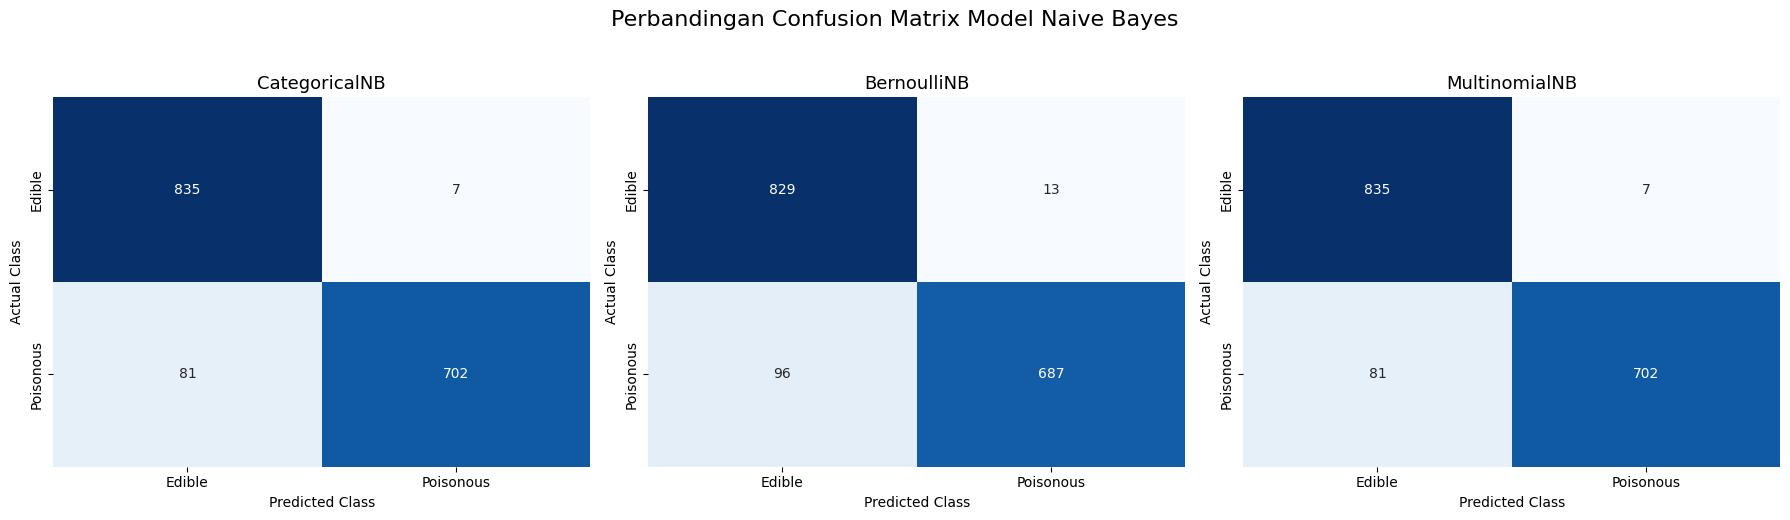

In [348]:
labels = ["e", "p"]

model_predictions = {
    "CategoricalNB": categorical_pred,
    "BernoulliNB": bernoulli_pred,
    "MultinomialNB": multinomial_pred
}

labels = [0, 1]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5)
)


for ax, (model_name, y_pred) in zip(
    axes,
    model_predictions.items()
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Edible",
            "Poisonous"
        ],
        yticklabels=[
            "Edible",
            "Poisonous"
        ],
        cbar=False,
        ax=ax
    )

    ax.set_title(
        model_name,
        fontsize=13
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "Actual Class"
    )


plt.suptitle(
    "Perbandingan Confusion Matrix Model Naive Bayes",
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

In [349]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

In [362]:
positive_label = 1

y_test_binary = y_test.astype(int)


def get_positive_probability(model, X_test_model, positive_label=1):
    positive_class_index = np.where(
        model.classes_ == positive_label
    )[0][0]

    probabilities = model.predict_proba(
        X_test_model
    )

    return probabilities[:, positive_class_index]

In [363]:
categorical_probability = get_positive_probability(
    categorical_nb,
    x_test_encoded,
    positive_label=1
)

bernoulli_probability = get_positive_probability(
    bernoulli_nb,
    x_test_onehot,
    positive_label=1
)

multinomial_probability = get_positive_probability(
    multinomial_nb,
    x_test_onehot,
    positive_label=1
)

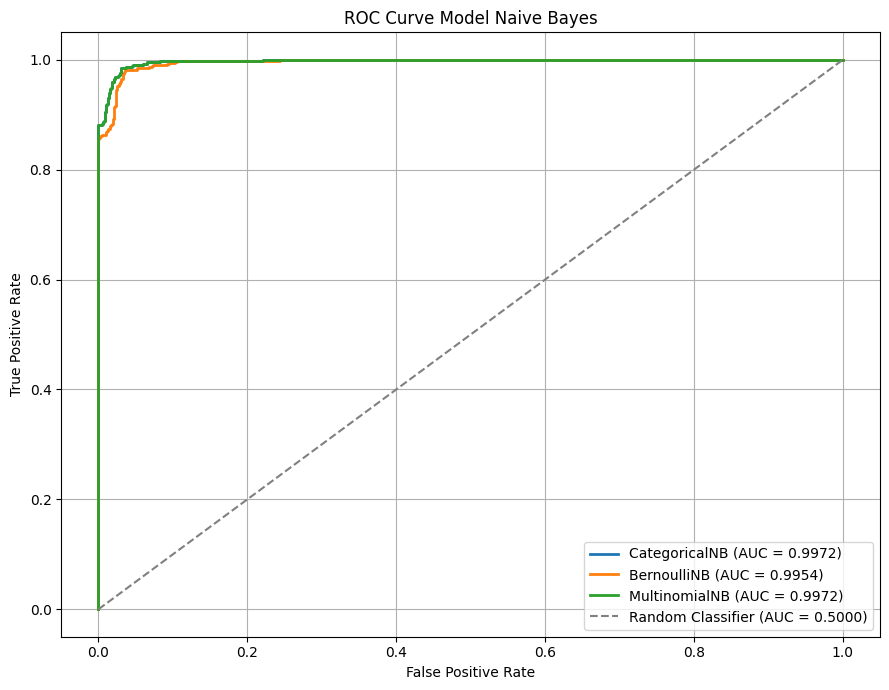

In [364]:
probability_results = {
    "CategoricalNB": categorical_probability,
    "BernoulliNB": bernoulli_probability,
    "MultinomialNB": multinomial_probability
}

plt.figure(figsize=(9, 7))

for model_name, y_probability in (probability_results.items()):
    # Menghitung titik-titik ROC
    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        y_probability
    )

    # Menghitung Area Under the Curve
    auc_score = roc_auc_score(
        y_test_binary,
        y_probability
    )

    # Menampilkan ROC setiap model
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {auc_score:.4f})"
        )
    )

# Garis baseline untuk tebakan acak
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Model Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [361]:
auc_results = []


for model_name, y_probability in (probability_results.items()):
    auc_score = roc_auc_score(
        y_test_binary,
        y_probability
    )

    auc_results.append({
        "Model": model_name,
        "AUC": auc_score
    })


auc_table = pd.DataFrame(auc_results)

auc_table = (
    auc_table
    .sort_values(
        by="AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(auc_table.round(4))

,Model,AUC
0,CategoricalNB,0.9972
1,MultinomialNB,0.9972
2,BernoulliNB,0.9954


# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan hasil eksperimen, CategoricalNB dan MultinomialNB menghasilkan performa yang identik dan menjadi dua model terbaik. Kedua model berhasil mengklasifikasikan 835 sampel edible dan 702 sampel poisonous dengan benar, sedangkan 7 sampel edible salah diprediksi sebagai poisonous dan 81 sampel poisonous salah diprediksi sebagai edible. Dari total 1.625 data testing, keduanya memperoleh accuracy sebesar 94,58%, precision sebesar 99,01%, recall sebesar 89,66%, dan F1-score sebesar 94,10%. Sementara itu, BernoulliNB memperoleh hasil sedikit lebih rendah dengan 829 prediksi edible dan 687 prediksi poisonous yang benar, serta melakukan 13 kesalahan pada sampel edible dan 96 kesalahan pada sampel poisonous. Hasil tersebut memberikan accuracy sebesar 93,29%, precision sebesar 98,14%, recall sebesar 87,74%, dan F1-score sebesar 92,65%. Selisih performa ini terutama terlihat pada kemampuan mengenali kelas poisonous, karena BernoulliNB melewatkan 96 sampel poisonous, lebih banyak daripada CategoricalNB dan MultinomialNB yang melewatkan 81 sampel.

Perbedaan performa tersebut berkaitan dengan representasi data yang digunakan. CategoricalNB menerima hasil OrdinalEncoder, sehingga setiap kolom asli tetap direpresentasikan sebagai satu fitur kategorikal dengan beberapa kemungkinan kategori. Representasi tersebut sesuai dengan karakteristik Mushroom Dataset yang seluruh fiturnya berbentuk kategori. Sebaliknya, BernoulliNB dan MultinomialNB menerima hasil OneHotEncoder, sehingga setiap kategori diubah menjadi fitur biner bernilai 0 atau 1. BernoulliNB memodelkan setiap hasil one-hot sebagai kejadian biner berupa ada atau tidak adanya suatu kategori. MultinomialNB sebenarnya dirancang untuk data frekuensi atau jumlah kemunculan, tetapi tetap dapat digunakan karena hasil one-hot bersifat nonnegatif. Walaupun CategoricalNB dan MultinomialNB menggunakan representasi berbeda, keduanya menghasilkan prediksi kelas akhir yang sama pada eksperimen ini. Hal tersebut menunjukkan bahwa informasi kategori pada data dapat dimanfaatkan secara sama baiknya oleh kedua model dalam pembagian data yang digunakan.

Hasil ROC Curve mendukung hasil evaluasi tersebut. CategoricalNB dan MultinomialNB sama-sama memperoleh AUC sebesar 0,9972, sedangkan BernoulliNB memperoleh AUC sebesar 0,9954. Ketiga nilai AUC tersebut sangat mendekati 1 dan seluruh kurvanya berada jauh di atas garis random classifier, sehingga ketiga model mempunyai kemampuan yang sangat baik dalam membedakan kelas edible dan poisonous pada berbagai nilai threshold. Meskipun perbedaan AUC ketiganya relatif kecil, CategoricalNB dan MultinomialNB tetap sedikit lebih unggul dan konsisten dengan hasil accuracy, recall, serta F1-score. Precision ketiga model sangat tinggi, tetapi recall lebih rendah daripada precision. Artinya, ketika model memprediksi suatu sampel sebagai poisonous, prediksi tersebut hampir selalu benar, tetapi masih terdapat sejumlah sampel poisonous yang salah diprediksi sebagai edible.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Berdasarkan keseluruhan hasil evaluasi, CategoricalNB dan MultinomialNB merupakan model terbaik dengan accuracy 94,58%, F1-score 94,10%, dan AUC 0,9972, sedangkan BernoulliNB menghasilkan performa sedikit lebih rendah. Walaupun CategoricalNB dan MultinomialNB memberikan hasil numerik yang sama, CategoricalNB lebih sesuai secara konseptual untuk dataset ini karena fitur asli memang berupa data kategorikal dan dapat direpresentasikan secara langsung sebagai kategori tanpa memperluasnya menjadi banyak kolom biner. BernoulliNB tetap menghasilkan performa yang sangat baik, tetapi asumsi setiap kolom one-hot sebagai kejadian biner menghasilkan lebih banyak kesalahan, terutama pada sampel poisonous. Sebagai pengembangan eksperimen, pengujian selanjutnya dapat membandingkan beberapa nilai parameter Laplace smoothing alpha, menggunakan stratified cross-validation agar hasil tidak hanya bergantung pada satu pembagian train-test, serta membandingkan perlakuan nilai "?" sebagai kategori unknown, imputasi modus, dan penghapusan kolom stalk.root. Fokus evaluasi berikutnya sebaiknya tidak hanya meningkatkan accuracy, tetapi juga meningkatkan recall kelas poisonous agar jumlah sampel poisonous yang salah diprediksi sebagai edible dapat dikurangi.

penggunaan AI pada tugas ini di khususkan untuk pengenalan dan cara penggunaan method, penyempurnaan teks analsisi dan kesimpulan saran sekaligus proses debug ketika saya salah cara menggunakan fungsi